In [4]:
import os
import librosa
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt

def split_audio_into_seconds(audio_file, segment_duration=5, output_folder="adult_lobsters"):
  """
  Splits an audio file into 1-second segments and saves them to a specified folder.

  Args:
    audio_file: Path to the audio file.
    segment_duration: Duration of each segment in seconds (default: 1 second).
    output_folder: Path to the output folder where segments will be saved. 

  Returns:
    None
  """

  # Create the output folder if it doesn't exist
  os.makedirs(output_folder, exist_ok=True) 

  y, sr = librosa.load(audio_file)
  samples_per_segment = int(sr * segment_duration)

  for i in range(0, len(y), samples_per_segment):
    segment = y[i:i + samples_per_segment]
    if len(segment) < samples_per_segment:
      # Pad the last segment with zeros to ensure consistent length
      segment = np.pad(segment, (0, samples_per_segment - len(segment)), 'constant') 
    segment_filename = os.path.join(output_folder, f"segment_{i // samples_per_segment}.wav") 
    sf.write(segment_filename, segment, sr)

# Example usage:
audio_file_path = "juvenile_lobsters.wav" 
output_directory = "juvenile_lobsters5"  # Create a folder named "audio_segments"
split_audio_into_seconds(audio_file_path, output_folder=output_directory)

110250
22050


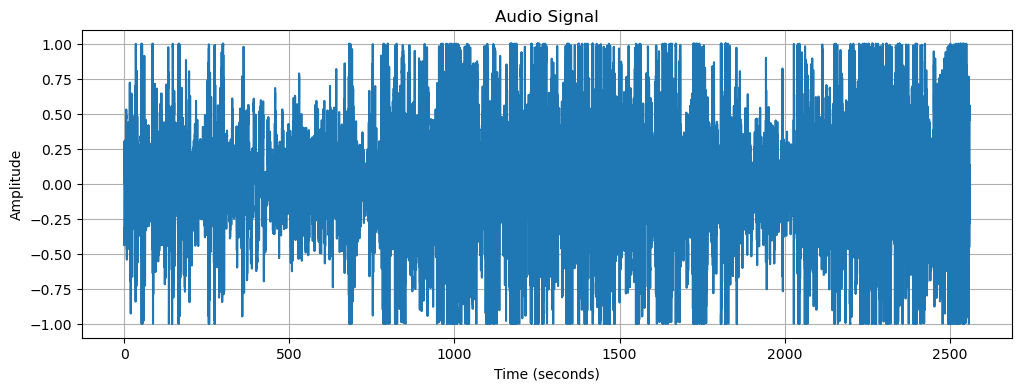

In [9]:
import librosa
import matplotlib.pyplot as plt

# Load the audio file
y1, sr1 = librosa.load('female_lobsters5/segment_1.wav') 

# y: Audio time series (numpy array)
# sr: Sampling rate (in Hz)

print(len(y1)) 
print(sr1) 
# Create time array
t1 = librosa.times_like(y1) 

# Plot the audio signal
plt.figure(figsize=(12, 4))
plt.plot(t1, y1)
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title('Audio Signal')
plt.grid(True)
plt.show()

110250


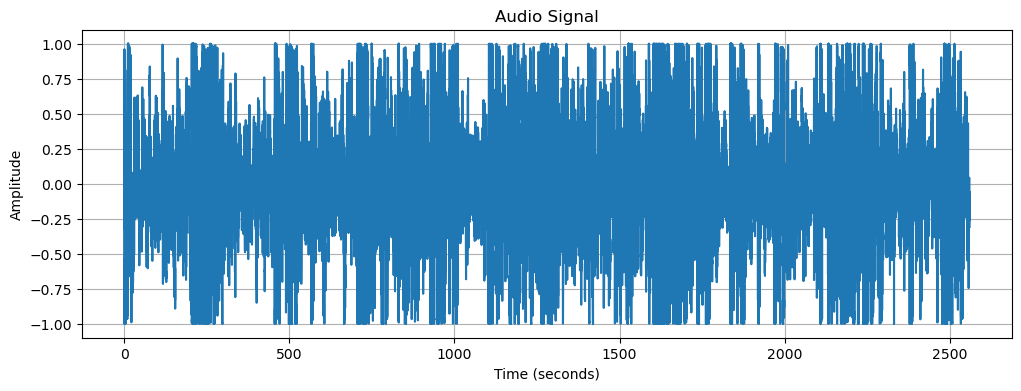

In [10]:
import librosa
import matplotlib.pyplot as plt

# Load the audio file
y2, sr2 = librosa.load('female_lobsters5/segment_0.wav') 

# y: Audio time series (numpy array)
# sr: Sampling rate (in Hz)

print(len(y2)) 
#print(sr2) 
# Create time array
t2 = librosa.times_like(y2) 

# Plot the audio signal
plt.figure(figsize=(12, 4))
plt.plot(t2, y2)
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title('Audio Signal')
plt.grid(True)
plt.show()

Number of files in 'female_lobsters5': 580
Number of files in 'male_lobsters5': 900
Number of files in 'adult_lobsters5': 1000
Number of files in 'juvenile_lobsters5': 480


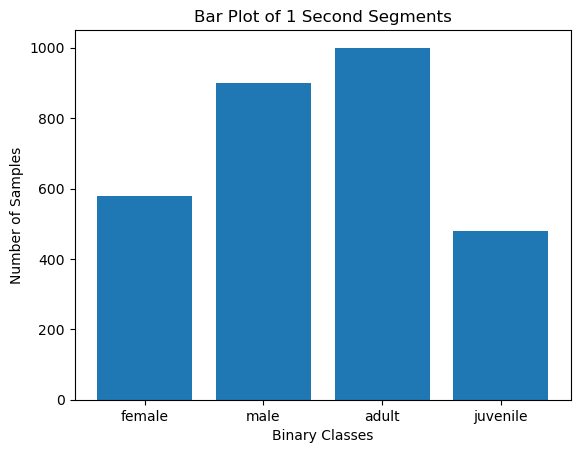

In [17]:
import os
import matplotlib.pyplot as plt


def count_files_in_directory(directory):
  """
  Counts the number of files within a given directory.

  Args:
    directory: The path to the directory.

  Returns:
    The number of files in the directory.
  """
  file_count = 0
  for root, dirs, files in os.walk(directory):
    file_count += len(files)
  return file_count

# Example usage:
directory_path2 = 'male_lobsters5'
directory_path1 = 'female_lobsters5'  # Replace with the actual directory path
directory_path3 = 'adult_lobsters5'
directory_path4 = 'juvenile_lobsters5'
num_files1 = count_files_in_directory(directory_path1)
num_files2 = count_files_in_directory(directory_path2)
num_files3 = count_files_in_directory(directory_path3)
num_files4 = count_files_in_directory(directory_path4)

print(f"Number of files in '{directory_path1}': {num_files1}")
print(f"Number of files in '{directory_path2}': {num_files2}")
print(f"Number of files in '{directory_path3}': {num_files3}")
print(f"Number of files in '{directory_path4}': {num_files4}")

# Data
x_labels = ["female", "male", "adult", "juvenile"]
y_values = [num_files1, num_files2, num_files3, num_files4]

# Create the bar plot
plt.bar(x_labels, y_values)

# Customize the plot
plt.xlabel("Binary Classes")
plt.ylabel("Number of Samples")
plt.title("Bar Plot of 1 Second Segments")

# Show the plot
plt.show()


In [15]:
import os
import librosa
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix

# Define paths to the folders
folder1_path = 'adult_lobsters5'  # Replace with the actual path to folder 1
folder2_path = 'juvenile_lobsters5'  # Replace with the actual path to folder 2

# Define parameters
sample_rate = 22050
n_fft = 2048
hop_length = 512
num_classes = 2  # Binary classification

# Load audio data and create labels
def load_data(folder_path):
    X = []
    y = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".wav"):  # Assuming WAV files
            file_path = os.path.join(folder_path, filename)
            audio, _ = librosa.load(file_path, sr=sample_rate)
            mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_fft=n_fft, hop_length=hop_length)
            X.append(mfccs.T)  # Transpose for Conv1D input
            y.append(1 if folder_path == folder1_path else 0)  # Label 1 for folder1, 0 for folder2
    return np.array(X), np.array(y)

# Load data for both folders
X1, y1 = load_data(folder1_path)
X2, y2 = load_data(folder2_path)

# Combine data from both folders
X = np.concatenate((X1, X2), axis=0)
y = np.concatenate((y1, y2), axis=0)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create 1D CNN model
model = Sequential()
model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

# Compile the model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary() 
# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
accuracy = accuracy_score(y_test, y_pred_labels)
print("Accuracy:", accuracy)

precision = precision_score(y_test, y_pred_labels, average='weighted')
print("Precision:", precision)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_labels)
print("Confusion Matrix:\n", cm)




/home/feliciano/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 214, 32)        │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 107, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 105, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 52, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3328)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       426,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 434,530 (1.66 MB)

 Trainable params: 434,530 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6371 - loss: 33.7028 - val_accuracy: 0.8243 - val_loss: 1.1764
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8149 - loss: 0.7205 - val_accuracy: 0.9155 - val_loss: 0.2223
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9564 - loss: 0.1277 - val_accuracy: 0.9561 - val_loss: 0.1943
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9723 - loss: 0.0876 - val_accuracy: 0.9291 - val_loss: 0.1663
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9689 - loss: 0.0718 - val_accuracy: 0.9392 - val_loss: 0.2244
Epoch 6/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9838 - loss: 0.0492 - val_accuracy: 0.9561 - val_loss: 0.1133
Epoch 7/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9961 - loss: 0.0230 - val_accuracy: 0.9324 - val_loss: 0.1678
Epoch 8/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9935 - loss: 0.0223 - val_accuracy: 0.9527 - val_los

In [16]:
import os
import librosa
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix


# Define paths to the folders
folder1_path = 'female_lobsters5'  # Replace with the actual path to folder 1
folder2_path = 'male_lobsters5'  # Replace with the actual path to folder 2

# Define parameters
sample_rate = 22050
n_fft = 2048
hop_length = 512
num_classes = 2  # Binary classification

# Load audio data and create labels
def load_data(folder_path):
    X = []
    y = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".wav"):  # Assuming WAV files
            file_path = os.path.join(folder_path, filename)
            audio, _ = librosa.load(file_path, sr=sample_rate)
            mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_fft=n_fft, hop_length=hop_length)
            X.append(mfccs.T)  # Transpose for Conv1D input
            y.append(1 if folder_path == folder1_path else 0)  # Label 1 for folder1, 0 for folder2
    return np.array(X), np.array(y)

# Load data for both folders
X1, y1 = load_data(folder1_path)
X2, y2 = load_data(folder2_path)

# Combine data from both folders
X = np.concatenate((X1, X2), axis=0)
y = np.concatenate((y1, y2), axis=0)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create 1D CNN model
model = Sequential()
model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

# Compile the model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary() 

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
accuracy = accuracy_score(y_test, y_pred_labels)
print("Accuracy:", accuracy)

precision = precision_score(y_test, y_pred_labels, average='weighted')
print("Precision:", precision)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_labels)
print("Confusion Matrix:\n", cm)

/home/feliciano/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 214, 32)        │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 107, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 105, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 52, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 3328)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       426,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 434,530 (1.66 MB)

 Trainable params: 434,530 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5612 - loss: 40.2869 - val_accuracy: 0.6588 - val_loss: 0.9511
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7210 - loss: 0.6480 - val_accuracy: 0.6993 - val_loss: 0.6760
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8227 - loss: 0.3973 - val_accuracy: 0.7264 - val_loss: 0.6045
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8788 - loss: 0.3165 - val_accuracy: 0.7399 - val_loss: 0.5161
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8805 - loss: 0.2720 - val_accuracy: 0.7162 - val_loss: 0.6560
Epoch 6/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9175 - loss: 0.2012 - val_accuracy: 0.7669 - val_loss: 0.5805
Epoch 7/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9443 - loss: 0.1502 - val_accuracy: 0.7973 - val_loss: 0.5010
Epoch 8/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9719 - loss: 0.1011 - val_accuracy: 0.8142 - val_los